In [ ]:
import re
import pandas as pd

In [ ]:
with open("_chat 3.txt", "r", encoding="utf-8") as f:
    next(f)
    data = f.read()

In [ ]:
# with open("_chat 4.txt", "r", encoding="utf-8") as f:
#     # Read all lines and slice from the second line (index 1) to the end
#     lines = f.readlines()[1:]
#     # Join them back into a single string for your preprocessor
#     data2 = "".join(lines)

In [ ]:
# print(data)

In [ ]:
print(type(data))

<class 'str'>


In [ ]:
dates = re.findall(r"\[\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}:\d{2}\]", data)


In [ ]:
messages = re.split(r"\[\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}:\d{2}\]\s", data)

# First element is junk (text before first date), remove it
messages = messages[1:]

In [ ]:
messages

['Nileshwari: दूधाला दुःख दिले की दही बनते. दह्याला दुखावले की ताक बनते. ताकाला त्रास दिला तर लोणी बनते आणि लोण्याला लोळवले तर तूप बनते. दुधापेक्षा दही महाग. दह्यापेक्षा ताक महाग. ताकापेक्षा लोणी महाग.  लोण्यापेक्षा तूप महाग. परंतु या सर्वांचा रंग एकच, शुभ्र! याचाच अर्थ पुन्हा पुन्हा संकटे आणि दुःख झेलुनही जो माणुस आपला रंग बदलत नाही, अश्या माणसाची समाजातील किंमत जास्त असते. दूध उपयोगी आहे पण एक दिवसात नासते. दूधाचे विरजण दही, दोन दिवस टिकेल. दह्याच्या घुसळलेल्या ताकाचे दिवस तीन. ताकामधले लोणी आठवडाभर राहील. पण लोण्याचे कढवलेले तूप मात्र कधीही खराब होत नाही. आता बघा आहे की नाही गंमत, एका दिवसातच नासण्याऱ्या दूधात कधीही न नासणारे तूप लपले आहे...! \n*तसेच आपले मन अथांग आहे.  त्यात सकारात्मक विचार घालून नीट मंथन करा...! चिंतन करा, मनन करा आणि आपले जीवन तावुन सुलाखून त्यातुनच  बाहेर पडलेले, म्हणजे कधीही न हरणारे आपले स्वत:चे एक सदाबहार व दिलखुलास व्यक्तीमत्व असू द्या.🌹🌹🙏🙏Good morning\n',
 'Nileshwari: Many many happy returns of the day suyesha..have fun 🎂🎂🎂🥳🥳🥳\n',
 'Vahini: Happy birthday 

In [ ]:
import pandas as pd
import re

with open("_chat 3.txt", "r", encoding="utf-8") as f:
    data = f.read()

pattern = r"\[(\d{1,2}/\d{1,2}/\d{2,4}),\s(\d{1,2}:\d{2}:\d{2})\]\s([^:]+):\s(.*)"

messages = re.findall(pattern, data)

df = pd.DataFrame(messages, columns=["date", "time", "user", "message"])

In [ ]:
df

,date,time,user,message
0,04/03/2022,22:39:19,💅🏻👠Pretty 💄Women💃🏻,‎Messages and calls are end-to-end encrypted. ...
1,05/03/2022,08:29:27,Nileshwari,दूधाला दुःख दिले की दही बनते. दह्याला दुखावले ...
2,07/03/2022,08:40:27,Nileshwari,Many many happy returns of the day suyesha..ha...
3,07/03/2022,09:36:19,Vahini,Happy birthday Suyasha🎂💐
4,07/03/2022,10:14:50,Prajakta,Happy Birthday Suyesha....🎉🎂🍻❤️
...,...,...,...,...
3364,14/04/2026,09:24:05,Mummy,फोटो छान आहेत
3365,14/04/2026,11:07:57,Aai,‎GIF omitted
3366,14/04/2026,11:11:02,Sneha,Wow superb😍😍😍 Wonderful pictures ❤️❤️❤️
3367,14/04/2026,11:11:31,Sneha,Shubhata looking very beautiful 😘😘😘


In [ ]:
print(df['date'].dtype)

object


In [ ]:
df['date'] = df['date'].str.strip('[]')
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [ ]:
df['date'] = pd.to_datetime(
    df['date'],
    format="%d/%m/%Y, %H:%M:%S",
    errors='coerce'
)

In [ ]:
print(df['date'].dtype)

datetime64[ns]


In [ ]:
# 1. Combine 'date' and 'time' strings and convert to datetime
df['full_date'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))

# 2. Now extract the components from the combined column
df['year'] = df['full_date'].dt.year
df['month'] = df['full_date'].dt.month_name()
df['day'] = df['full_date'].dt.day
df['hour'] = df['full_date'].dt.hour
df['minute'] = df['full_date'].dt.minute

In [ ]:
df.sample(10)

,date,time,user,message,full_date,year,month,day,hour,minute
2674,2025-07-02,22:07:54,Shubhata,‎image omitted,2025-07-02 22:07:54,2025,July,2,22,7
1603,2023-12-04,08:38:11,Nileshwari,‎image omitted,2023-12-04 08:38:11,2023,December,4,8,38
1370,2023-09-06,05:53:21,Varsha Rashinkar,Arey wah mastach Rakhi celebration ❤️😍,2023-09-06 05:53:21,2023,September,6,5,53
2724,2025-07-02,22:09:11,Shubhata,‎image omitted,2025-07-02 22:09:11,2025,July,2,22,9
2109,2024-09-14,14:19:21,Mummy,*॥ ॐ नमो नारायणाय ॥*,2024-09-14 14:19:21,2024,September,14,14,19
666,2022-10-31,10:30:44,Mummy,*आरे दूध*,2022-10-31 10:30:44,2022,October,31,10,30
1342,2023-09-04,09:07:14,Aai,‎image omitted,2023-09-04 09:07:14,2023,September,4,9,7
2003,2024-06-21,19:13:16,Varsha Rashinkar,😀😀,2024-06-21 19:13:16,2024,June,21,19,13
162,2022-03-26,18:34:26,Shubhata,‎image omitted,2022-03-26 18:34:26,2022,March,26,18,34
2259,2024-12-04,13:41:01,Mummy,🌹⚜️🌸🔆🌅🔆🌸⚜️🌹,2024-12-04 13:41:01,2024,December,4,13,41


In [ ]:
print(df['date'].dtype)

datetime64[ns]


In [ ]:
df['user'].unique()

array(['💅🏻👠Pretty 💄Women💃🏻', 'Nileshwari', 'Vahini', 'Prajakta',
       'Urvashi', 'Aai', 'Poonam Kaki 2', 'Suyesha', 'Shubhata', 'Sneha',
       '~\u202fAparna Patalay', 'Mummy', 'Varsha Rashinkar', 'Urvi',
       'Vidya Kaki', 'Ira & Reva', 'Kishore Kaka', 'Aparna 2'],
      dtype=object)

In [ ]:
!pip install urlextract

In [ ]:
from urlextract import URLExtract
extractor = URLExtract()

In [ ]:
links = []
for message in df['message']:
  links.extend(extractor.find_urls(message))

In [ ]:
len(links)

96

In [ ]:
from collections import Counter

In [ ]:
words = []
for message in df['message']:
  words.extend(message.split())

count = Counter(words).most_common(20)
pd.DataFrame(count, columns=['Word', 'Count'])

,Word,Count
0,omitted,1648
1,‎image,1152
2,‎video,431
3,Happy,233
4,you,129
5,खूप,111
6,Thank,109
7,birthday,84
8,Birthday,79
9,and,78


In [ ]:
df[df['user'] == 'group_notification']

,date,time,user,message,full_date,year,month,day,hour,minute


In [ ]:
temp = df[~df['message'].str.contains('omitted', case=False, na=False)]

In [ ]:
# to remove stopwords
f = open('stop_hinglish.txt', 'r')
stop_words = f.read().split()

In [ ]:
words = []

for message in temp['message']:
    for word in message.lower().split():
        if word not in stop_words:
            words.append(word)

# Count most common words
count = Counter(words).most_common(20)

# Convert to DataFrame
common_df = pd.DataFrame(count, columns=['Word', 'Count'])
common_df

,Word,Count
0,happy,237
1,birthday,153
2,खूप,106
3,anniversary,71
4,message,59
5,dear,55
6,‎this,50
7,kaki,48
8,deleted.,48
9,❤️,46


In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.7 MB/s eta 0:00:00


In [ ]:
import emoji

In [ ]:
emojis = []
for message in df['message']:
  for c in message:
    if c in emoji.EMOJI_DATA:
      emojis.append(c)

In [ ]:
emojis

['🎂',
 '🎂',
 '🎂',
 '🥳',
 '🥳',
 '🥳',
 '🎂',
 '💐',
 '🎉',
 '🎂',
 '🍻',
 '❤',
 '🍾',
 '🎊',
 '🎂',
 '🎉',
 '🍔',
 '🍟',
 '🍿',
 '🍫',
 '🎂',
 '🍰',
 '😘',
 '😊',
 '😘',
 '😘',
 '😘',
 '🎂',
 '❤',
 '😘',
 '💓',
 '🎂',
 '🍫',
 '🎉',
 '🎊',
 '😘',
 '🎂',
 '🎉',
 '👌',
 '👍',
 '😊',
 '🙏',
 '🙏',
 '🤪',
 '😀',
 '😀',
 '🙏',
 '🙏',
 '🙏',
 '🙏',
 '🙏',
 '🌺',
 '🙏',
 '🌺',
 '🙏',
 '🙏',
 '🙏',
 '🙏',
 '🙏',
 '🙏',
 '👏',
 '💜',
 '🔥',
 '🎉',
 '❤',
 '😄',
 '😄',
 '👍',
 '👍',
 '😔',
 '👌',
 '👌',
 '👌',
 '👌',
 '👌',
 '👌',
 '😍',
 '😍',
 '😍',
 '❤',
 '❤',
 '❤',
 '🤗',
 '🤗',
 '🤗',
 '😘',
 '😘',
 '😘',
 '💋',
 '👌',
 '👌',
 '😘',
 '😘',
 '😘',
 '❤',
 '❤',
 '👍',
 '👍',
 '👆',
 '👏',
 '👏',
 '👏',
 '👏',
 '👌',
 '👌',
 '👌',
 '👍',
 '👍',
 '👌',
 '👌',
 '👌',
 '👌',
 '👌',
 '😍',
 '😍',
 '😘',
 '💐',
 '🚩',
 '🎉',
 '🙏',
 '🙏',
 '🌹',
 '🙏',
 '🙏',
 '🙏',
 '🌹',
 '🙏',
 '❤',
 '❤',
 '❤',
 '😍',
 '😍',
 '😍',
 '🤗',
 '🤗',
 '❤',
 '❤',
 '❤',
 '😘',
 '😘',
 '😘',
 '😘',
 '❤',
 '❤',
 '❤',
 '🙏',
 '🙏',
 '🙏',
 '💐',
 '☹',
 '😟',
 '❤',
 '😊',
 '👍',
 '🌹',
 '👍',
 '🙏',
 '🌹',
 '👌',
 '👌',
 '❤',
 '❤',
 '👌',
 '👌',
 '👌',
 '🕉',
 '🕉'

In [ ]:
pd.DataFrame(Counter(emojis).most_common(len(Counter(emojis))), columns=['Emoji', 'Count'])

,Emoji,Count
0,🙏,520
1,👌,355
2,❤,247
3,🏻,185
4,🎂,184
...,...,...
150,🎷,1
151,💍,1
152,🌟,1
153,🌪,1


In [ ]:
df['month_num'] = df['date'].dt.month

In [ ]:
df

,date,time,user,message,full_date,year,month,day,hour,minute,month_num
0,2022-03-04,22:39:19,💅🏻👠Pretty 💄Women💃🏻,‎Messages and calls are end-to-end encrypted. ...,2022-03-04 22:39:19,2022,March,4,22,39,3
1,2022-03-05,08:29:27,Nileshwari,दूधाला दुःख दिले की दही बनते. दह्याला दुखावले ...,2022-03-05 08:29:27,2022,March,5,8,29,3
2,2022-03-07,08:40:27,Nileshwari,Many many happy returns of the day suyesha..ha...,2022-03-07 08:40:27,2022,March,7,8,40,3
3,2022-03-07,09:36:19,Vahini,Happy birthday Suyasha🎂💐,2022-03-07 09:36:19,2022,March,7,9,36,3
4,2022-03-07,10:14:50,Prajakta,Happy Birthday Suyesha....🎉🎂🍻❤️,2022-03-07 10:14:50,2022,March,7,10,14,3
...,...,...,...,...,...,...,...,...,...,...,...
3364,2026-04-14,09:24:05,Mummy,फोटो छान आहेत,2026-04-14 09:24:05,2026,April,14,9,24,4
3365,2026-04-14,11:07:57,Aai,‎GIF omitted,2026-04-14 11:07:57,2026,April,14,11,7,4
3366,2026-04-14,11:11:02,Sneha,Wow superb😍😍😍 Wonderful pictures ❤️❤️❤️,2026-04-14 11:11:02,2026,April,14,11,11,4
3367,2026-04-14,11:11:31,Sneha,Shubhata looking very beautiful 😘😘😘,2026-04-14 11:11:31,2026,April,14,11,11,4


In [ ]:
timeline = df.groupby(['year', 'month_num', 'month']).count()['message'].reset_index()

In [ ]:
timeline

,year,month_num,month,message
0,2022,3,March,219
1,2022,4,April,52
2,2022,5,May,78
3,2022,6,June,31
4,2022,7,July,31
5,2022,8,August,54
6,2022,9,September,70
7,2022,10,October,132
8,2022,11,November,131
9,2022,12,December,184


In [ ]:
timeline.shape

(50, 5)

In [ ]:
time

['March - 2022',
 'April - 2022',
 'May - 2022',
 'June - 2022',
 'July - 2022',
 'August - 2022',
 'September - 2022',
 'October - 2022',
 'November - 2022',
 'December - 2022',
 'January - 2023',
 'February - 2023',
 'March - 2023',
 'April - 2023',
 'May - 2023',
 'June - 2023',
 'July - 2023',
 'August - 2023',
 'September - 2023',
 'October - 2023',
 'November - 2023',
 'December - 2023',
 'January - 2024',
 'February - 2024',
 'March - 2024',
 'April - 2024',
 'May - 2024',
 'June - 2024',
 'July - 2024',
 'August - 2024',
 'September - 2024',
 'October - 2024',
 'November - 2024',
 'December - 2024',
 'January - 2025',
 'February - 2025',
 'March - 2025',
 'April - 2025',
 'May - 2025',
 'June - 2025',
 'July - 2025',
 'August - 2025',
 'September - 2025',
 'October - 2025',
 'November - 2025',
 'December - 2025',
 'January - 2026',
 'February - 2026',
 'March - 2026',
 'April - 2026']

In [ ]:
timeline['time'] = time

In [ ]:
import matplotlib.pyplot as plt

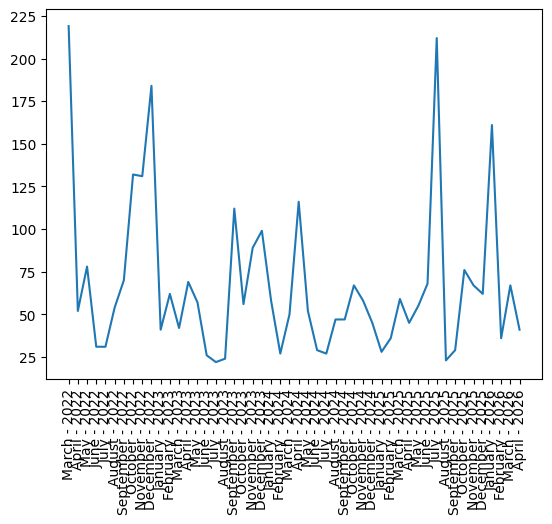

In [ ]:
plt.plot(timeline['time'], timeline['message'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
df['only_date'] = df['date'].dt.date

In [ ]:
daily_timeline = df.groupby('only_date').count()['message'].reset_index()

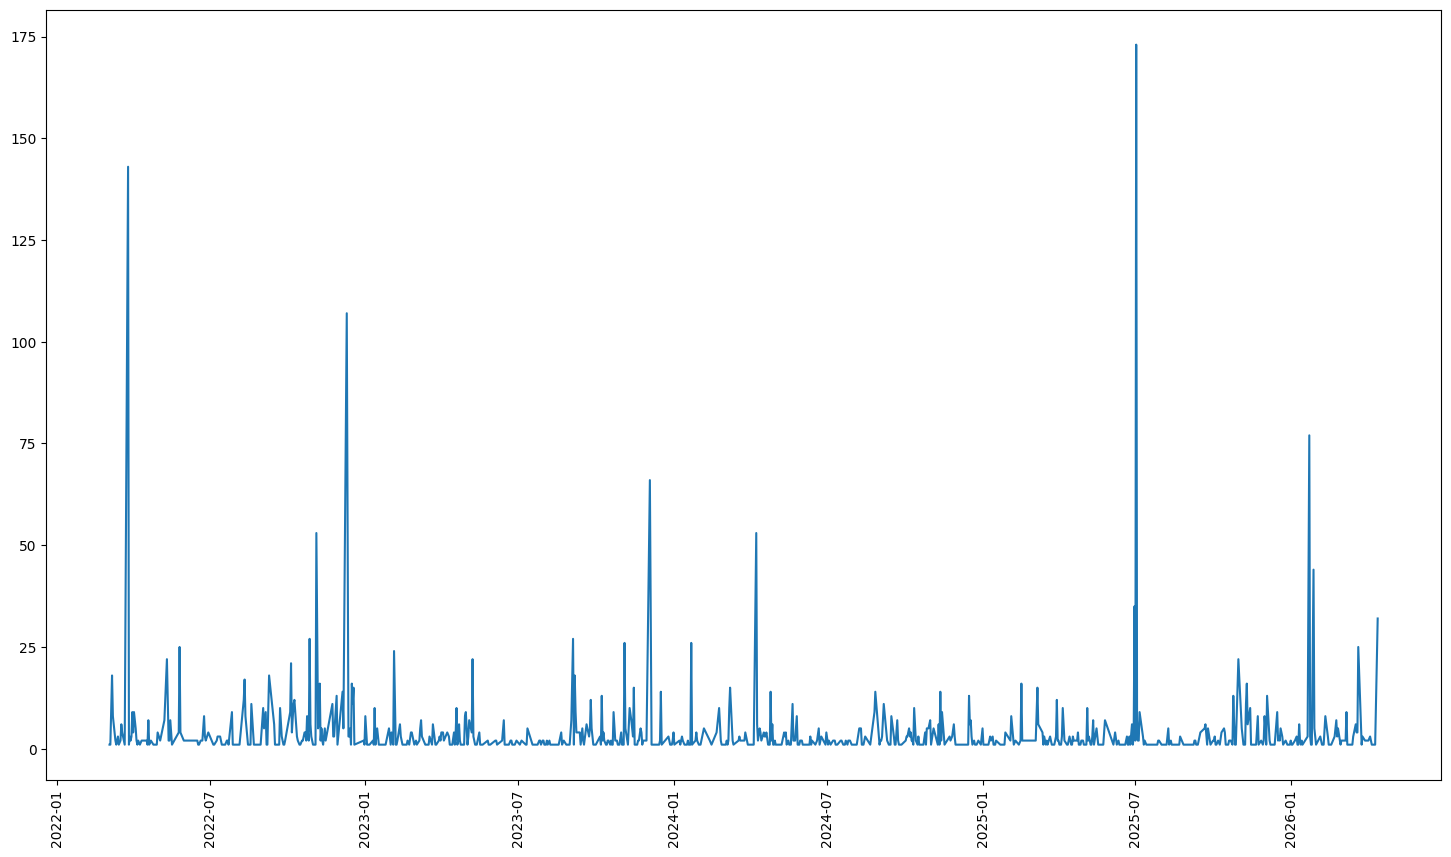

In [ ]:
plt.figure(figsize=(18, 10))
plt.plot(daily_timeline['only_date'], daily_timeline['message'])
plt.xticks(rotation='vertical')
plt.show()